# Experiment 5: Image Classification using CNN

**Course:** AML ZC417 – Introduction to Deep Learning
**Module Reference:** Module 7 — Convolutional Neural Networks
**Duration:** 2 hours

---

## Aim
To build, train, and evaluate a Convolutional Neural Network (CNN) for image classification, and to understand the role of convolutional layers, pooling layers, and feature maps in learning visual patterns directly from pixel data.

## Learning Outcomes
By the end of this experiment, you will be able to:
1. Explain the roles of convolution, padding, stride, and pooling in a CNN.
2. Build a CNN architecture using Keras (Conv2D, MaxPooling2D, Flatten, Dense layers).
3. Train and evaluate a CNN on an image classification task.
4. Visualize learned feature maps and filters to interpret what a CNN "sees".
5. Compare a CNN's performance against a plain DNN (from Experiment 3) on the same image task.
6. Use data augmentation to improve a CNN's generalization.


## Part 0 — Setup and Dataset

We use the **Fashion-MNIST dataset**: 28×28 grayscale images of 10 clothing categories (T-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle boot). It is a drop-in replacement for MNIST but is a noticeably harder task — better suited to showing the advantage of a CNN over a plain DNN.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


TensorFlow version: 2.21.0


In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# CNNs expect a channel dimension: (height, width, channels). Grayscale -> 1 channel.
x_train_full = x_train_full[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Hold out a validation set
x_train, x_val = x_train_full[:50000], x_train_full[50000:]
y_train, y_val = y_train_full[:50000], y_train_full[50000:]

print("Train shape:", x_train.shape, y_train.shape)
print("Validation shape:", x_val.shape, y_val.shape)
print("Test shape:", x_test.shape, y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step 
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step 
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 
Train shape: (50000, 28, 28, 1) (50000,)
Validation shape: (10000, 28, 28, 1) (10000,)
Test shape: (10000, 28, 28, 1) (10000,)


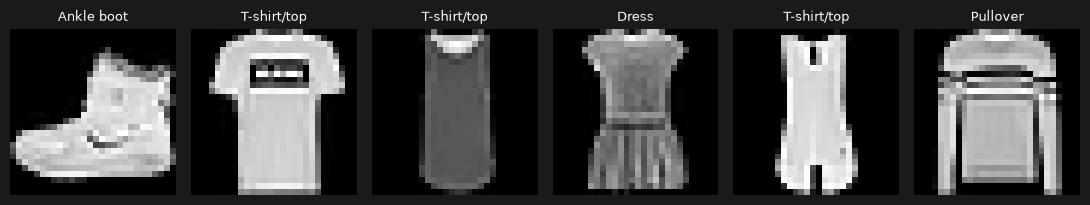

In [3]:
# Visualize a few samples
fig, axes = plt.subplots(1, 6, figsize=(11, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].squeeze(), cmap="gray")
    ax.set_title(class_names[y_train[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


---
## Part 1 — Why Not Just Use a Plain DNN?

A plain DNN (as in Experiment 3) treats an image as a flat vector of pixels, discarding all spatial structure — a pixel and its neighbour are treated no differently than two pixels on opposite corners of the image. A **Convolutional Neural Network (CNN)** instead:

- Uses small learnable filters (kernels) that **slide across the image**, detecting local patterns (edges, textures, shapes) regardless of *where* they appear (translation invariance).
- **Shares weights** across the whole image, drastically reducing the number of parameters compared to a fully connected layer of the same input size.
- Stacks convolutional layers to build a **hierarchy of features**: early layers detect edges/corners, deeper layers combine these into more complex shapes and object parts.

### 1.1 Baseline: Plain DNN on Fashion-MNIST (for comparison)


In [4]:
def build_dnn_baseline():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

dnn_model = build_dnn_baseline()
history_dnn = dnn_model.fit(x_train, y_train, validation_data=(x_val, y_val),
                             epochs=10, batch_size=64, verbose=2)

dnn_test_loss, dnn_test_acc = dnn_model.evaluate(x_test, y_test, verbose=0)
print(f"\nPlain DNN -- Test accuracy: {dnn_test_acc:.4f}")


Epoch 1/10
782/782 - 2s - 2ms/step - accuracy: 0.8119 - loss: 0.5306 - val_accuracy: 0.8519 - val_loss: 0.4199
Epoch 2/10
782/782 - 1s - 1ms/step - accuracy: 0.8620 - loss: 0.3814 - val_accuracy: 0.8637 - val_loss: 0.3793
Epoch 3/10
782/782 - 1s - 1ms/step - accuracy: 0.8768 - loss: 0.3388 - val_accuracy: 0.8680 - val_loss: 0.3647
Epoch 4/10
782/782 - 1s - 1ms/step - accuracy: 0.8847 - loss: 0.3138 - val_accuracy: 0.8719 - val_loss: 0.3533
Epoch 5/10
782/782 - 1s - 1ms/step - accuracy: 0.8918 - loss: 0.2926 - val_accuracy: 0.8762 - val_loss: 0.3492
Epoch 6/10
782/782 - 1s - 1ms/step - accuracy: 0.8971 - loss: 0.2773 - val_accuracy: 0.8769 - val_loss: 0.3451
Epoch 7/10
782/782 - 1s - 1ms/step - accuracy: 0.9016 - loss: 0.2643 - val_accuracy: 0.8799 - val_loss: 0.3345
Epoch 8/10
782/782 - 1s - 1ms/step - accuracy: 0.9061 - loss: 0.2527 - val_accuracy: 0.8824 - val_loss: 0.3382
Epoch 9/10
782/782 - 1s - 1ms/step - accuracy: 0.9103 - loss: 0.2417 - val_accuracy: 0.8836 - val_loss: 0.3390
E

---
## Part 2 — Building a CNN

A typical CNN architecture stacks **Conv2D -> Activation -> Pooling** blocks, then flattens the final feature maps into a vector for one or more Dense layers.

| Layer | Purpose |
|---|---|
| Conv2D | Applies learnable filters to detect local patterns; output is a stack of "feature maps." |
| MaxPooling2D | Downsamples feature maps (e.g. 2×2 -> 1 value), reducing spatial size and providing translation invariance. |
| Flatten | Converts the final 3D feature maps into a 1D vector for the Dense layers. |
| Dense | Standard fully connected layers for final classification, as in a plain DNN. |


In [5]:
def build_cnn():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(pool_size=2),

        keras.layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(pool_size=2),

        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn_model = build_cnn()
cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

**Reading the model summary:** Notice how the spatial size (28x28 -> 14x14 -> 7x7) shrinks after each MaxPooling2D layer, while the number of channels/filters (1 -> 32 -> 64) grows. This is the standard CNN pattern: trade spatial resolution for a richer feature representation.


In [6]:
history_cnn = cnn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=2,
)


Epoch 1/10
782/782 - 7s - 8ms/step - accuracy: 0.7938 - loss: 0.5784 - val_accuracy: 0.8710 - val_loss: 0.3550
Epoch 2/10
782/782 - 6s - 7ms/step - accuracy: 0.8669 - loss: 0.3765 - val_accuracy: 0.8898 - val_loss: 0.3028
Epoch 3/10
782/782 - 6s - 7ms/step - accuracy: 0.8833 - loss: 0.3235 - val_accuracy: 0.9013 - val_loss: 0.2699
Epoch 4/10
782/782 - 7s - 9ms/step - accuracy: 0.8937 - loss: 0.2944 - val_accuracy: 0.9046 - val_loss: 0.2609
Epoch 5/10
782/782 - 7s - 9ms/step - accuracy: 0.9022 - loss: 0.2710 - val_accuracy: 0.9088 - val_loss: 0.2480
Epoch 6/10
782/782 - 7s - 8ms/step - accuracy: 0.9084 - loss: 0.2513 - val_accuracy: 0.9165 - val_loss: 0.2344
Epoch 7/10
782/782 - 7s - 8ms/step - accuracy: 0.9141 - loss: 0.2328 - val_accuracy: 0.9124 - val_loss: 0.2367
Epoch 8/10
782/782 - 7s - 8ms/step - accuracy: 0.9208 - loss: 0.2152 - val_accuracy: 0.9189 - val_loss: 0.2268
Epoch 9/10
782/782 - 6s - 8ms/step - accuracy: 0.9242 - loss: 0.2051 - val_accuracy: 0.9183 - val_loss: 0.2303
E

In [7]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"CNN -- Test accuracy: {cnn_test_acc:.4f}, Test loss: {cnn_test_loss:.4f}")
print(f"\nComparison:")
print(f"  Plain DNN test accuracy: {dnn_test_acc:.4f}")
print(f"  CNN test accuracy:       {cnn_test_acc:.4f}")


CNN -- Test accuracy: 0.9109, Test loss: 0.2568

Comparison:
  Plain DNN test accuracy: 0.8751
  CNN test accuracy:       0.9109


### 2.1 Plotting Training Curves

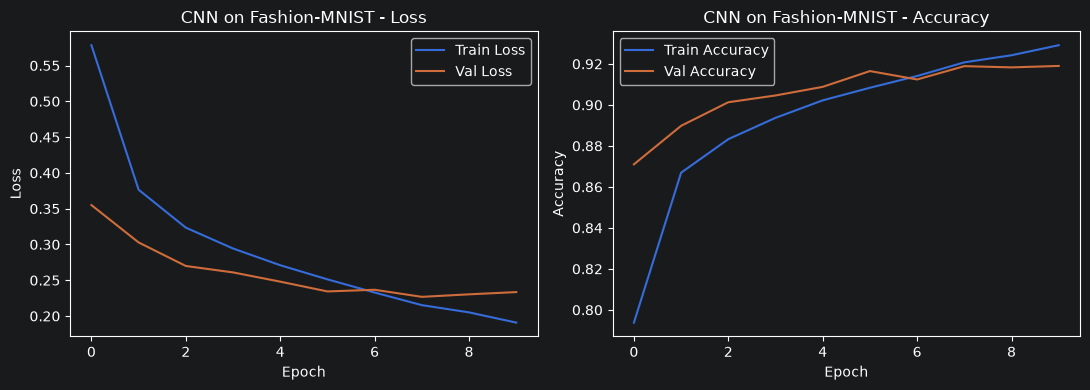

In [8]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title(f"{title} - Loss")

    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].set_title(f"{title} - Accuracy")
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "CNN on Fashion-MNIST")


---
## Part 3 — Evaluating Predictions


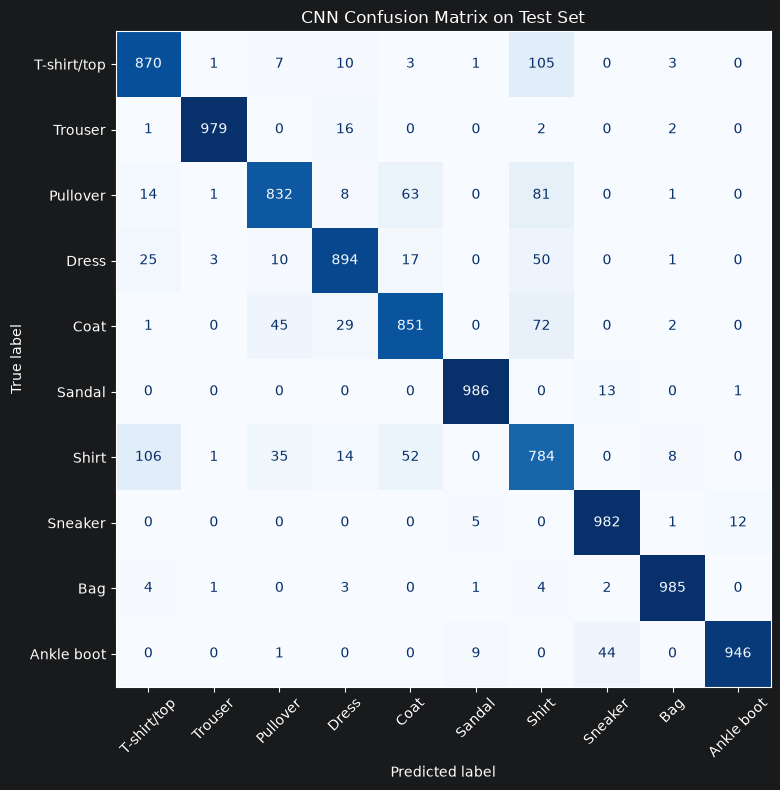

In [10]:
y_pred_probs = cnn_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("CNN Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


**What to look for:** Most errors should cluster among visually similar classes (e.g. "Shirt" vs. "T-shirt/top" vs. "Coat" vs. "Pullover" — all upper-body garments), while very distinct classes (e.g. "Trouser," "Bag," "Sandal") should have very few errors.


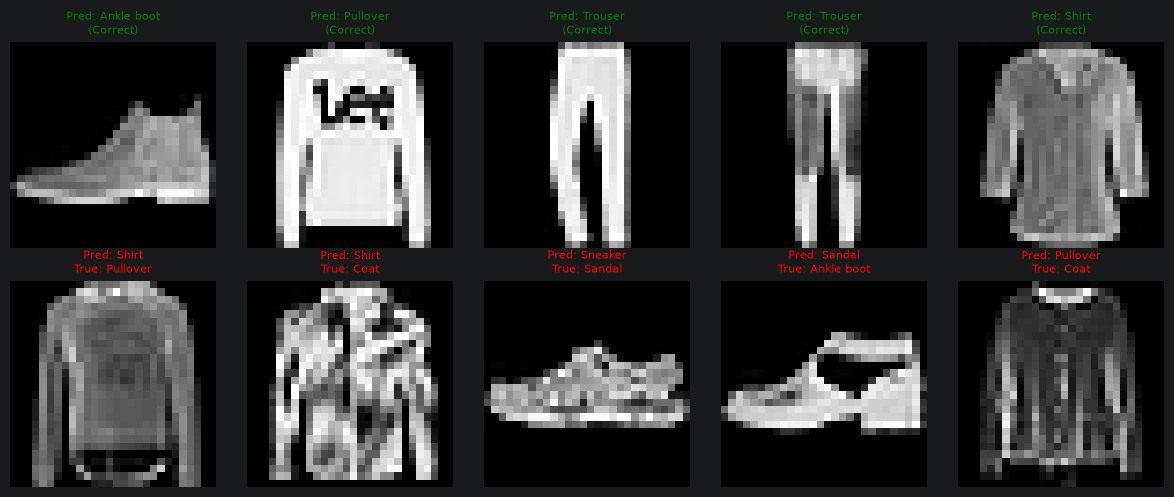

In [11]:
# Show a few correctly and incorrectly classified examples
correct_idx = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    idx = correct_idx[i]
    axes[0, i].imshow(x_test[idx].squeeze(), cmap="gray")
    axes[0, i].set_title(f"Pred: {class_names[y_pred[idx]]}\n(Correct)", fontsize=8, color="green")
    axes[0, i].axis("off")

    idx = incorrect_idx[i]
    axes[1, i].imshow(x_test[idx].squeeze(), cmap="gray")
    axes[1, i].set_title(f"Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[y_test[idx]]}", fontsize=8, color="red")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


---
## Part 4 — Visualizing Learned Feature Maps

To understand what the CNN has learned, we can inspect the **feature maps** (the output of a convolutional layer) for a single test image. Early layers typically respond to edges and simple textures.


Feature map shape: (1, 28, 28, 32)


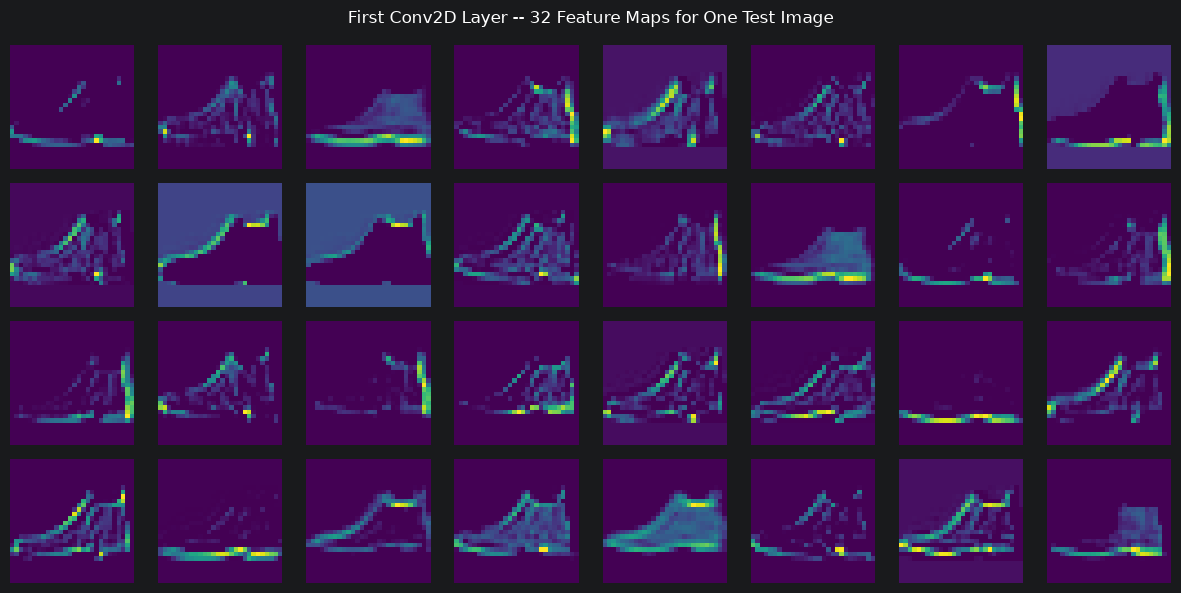

In [12]:
# Build a model that outputs the activations of the first Conv2D layer
first_conv_layer = cnn_model.layers[0]
activation_model = keras.Model(inputs=cnn_model.inputs, outputs=first_conv_layer.output)

sample_image = x_test[0:1]   # keep batch dimension
feature_maps = activation_model.predict(sample_image, verbose=0)
print("Feature map shape:", feature_maps.shape)   # (1, 28, 28, 32) -- 32 filters

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, :, :, i], cmap="viridis")
    ax.axis("off")
plt.suptitle("First Conv2D Layer -- 32 Feature Maps for One Test Image")
plt.tight_layout()
plt.show()


**What to look for:** Each of the 32 small images is the response of one learned filter to the same input image. Some filters highlight edges/outlines, others respond to particular textures or regions — this is the CNN "seeing" the image through different learned lenses.


---
## Part 5 — Data Augmentation

**Data augmentation** artificially expands the training set by applying random, label-preserving transformations (flips, rotations, zooms) to training images on the fly. This helps the CNN generalize better and reduces overfitting, especially on smaller datasets.


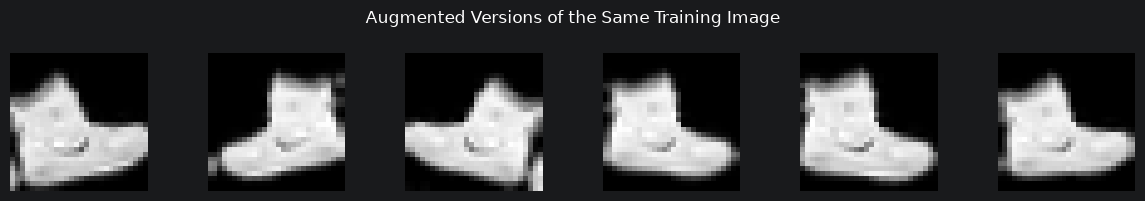

In [13]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.05),
    keras.layers.RandomZoom(0.1),
])

# Visualize augmented versions of one image
sample = x_train[0:1]
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axes):
    augmented = data_augmentation(sample, training=True)
    ax.imshow(augmented[0].numpy().squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Augmented Versions of the Same Training Image")
plt.tight_layout()
plt.show()


In [14]:
def build_cnn_with_augmentation():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),
        data_augmentation,

        keras.layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(pool_size=2),

        keras.layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(pool_size=2),

        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn_aug_model = build_cnn_with_augmentation()
history_aug = cnn_aug_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=2,
)

aug_test_loss, aug_test_acc = cnn_aug_model.evaluate(x_test, y_test, verbose=0)
print(f"\nCNN with augmentation -- Test accuracy: {aug_test_acc:.4f}")


Epoch 1/10
782/782 - 8s - 11ms/step - accuracy: 0.7192 - loss: 0.7574 - val_accuracy: 0.8185 - val_loss: 0.4772
Epoch 2/10
782/782 - 8s - 10ms/step - accuracy: 0.7998 - loss: 0.5423 - val_accuracy: 0.8431 - val_loss: 0.4182
Epoch 3/10
782/782 - 8s - 10ms/step - accuracy: 0.8213 - loss: 0.4901 - val_accuracy: 0.8581 - val_loss: 0.3820
Epoch 4/10
782/782 - 8s - 10ms/step - accuracy: 0.8325 - loss: 0.4544 - val_accuracy: 0.8579 - val_loss: 0.3824
Epoch 5/10
782/782 - 8s - 10ms/step - accuracy: 0.8439 - loss: 0.4318 - val_accuracy: 0.8748 - val_loss: 0.3373
Epoch 6/10
782/782 - 7s - 10ms/step - accuracy: 0.8514 - loss: 0.4101 - val_accuracy: 0.8774 - val_loss: 0.3317
Epoch 7/10
782/782 - 7s - 10ms/step - accuracy: 0.8561 - loss: 0.3950 - val_accuracy: 0.8798 - val_loss: 0.3251
Epoch 8/10
782/782 - 7s - 10ms/step - accuracy: 0.8620 - loss: 0.3825 - val_accuracy: 0.8815 - val_loss: 0.3187
Epoch 9/10
782/782 - 7s - 10ms/step - accuracy: 0.8665 - loss: 0.3682 - val_accuracy: 0.8884 - val_loss:

In [15]:
print(f"{'Model':<28}{'Test Accuracy':>15}")
print("-" * 43)
print(f"{'Plain DNN':<28}{dnn_test_acc:>15.4f}")
print(f"{'CNN':<28}{cnn_test_acc:>15.4f}")
print(f"{'CNN + Augmentation':<28}{aug_test_acc:>15.4f}")


Model                         Test Accuracy
-------------------------------------------
Plain DNN                            0.8751
CNN                                  0.9109
CNN + Augmentation                   0.8793


**Note:** Data augmentation is most beneficial when training data is limited or when the model is overfitting. With Fashion-MNIST's full 50,000-image training set and only 10 epochs, the improvement from augmentation may be modest — its value becomes more apparent with fewer training samples or longer training runs.


---
## Part 6 — In-Lab Exercise (to be completed and shown to the instructor)

1. Add a **third Conv2D + MaxPooling2D block** (e.g. 128 filters) to the CNN architecture from Part 2. Does test accuracy improve, stay the same, or get worse? Explain in a markdown cell.
2. Replace all `MaxPooling2D` layers with `AveragePooling2D` and retrain. Compare the final test accuracy to the max-pooling version.
3. Visualize the feature maps of the **second** Conv2D layer (instead of the first) for the same test image. How do these feature maps look different from the first layer's? What does this suggest about what deeper layers learn?
4. Try **two additional data augmentation transforms** not used in Part 5 (e.g. `RandomContrast`, `RandomTranslation`) and retrain. Report the resulting test accuracy.
5. In 3–4 sentences, summarize: (a) how much improvement the CNN gave over the plain DNN, and (b) whether data augmentation helped in your specific run, with a possible reason why or why not.


In [16]:
# TODO 1: Add a third Conv2D + MaxPooling2D block
# your code here


_TODO 1 (continued): Your explanation here._

In [17]:
# TODO 2: Replace MaxPooling2D with AveragePooling2D
# your code here


In [18]:
# TODO 3: Visualize feature maps of the second Conv2D layer
# your code here


_TODO 3 (continued): Your explanation here._

In [19]:
# TODO 4: Additional data augmentation transforms
# your code here


_TODO 5: Your summary here._

---
## Post-Lab Viva Questions

1. Why is a CNN generally better suited to image data than a plain fully connected DNN?
2. What is the effect of a MaxPooling2D layer on the spatial dimensions and the number of channels of its input?
3. What does "weight sharing" mean in the context of a convolutional filter, and why does it reduce the number of parameters?
4. Why do we add a channel dimension (reshape to (28,28,1)) before feeding grayscale images into a CNN?
5. What is the purpose of data augmentation, and why is it applied only during training, not during evaluation?
6. Looking at the confusion matrix, which classes were most often confused with each other, and why does that make visual sense?

---
*End of Experiment 5*
